# Prototype get gfw sar data

In [2]:
# gfw_s2_vessel_detections_min.py
from google.cloud import bigquery
import pandas as pd
import os 
import gfwapiclient as gfw
import matplotlib.pyplot as plt

In [3]:
year = 2025
temporal_granularity = 'DAILY'

start_month = '01'
start_day = '01'

end_month = '12'
end_day = '31'

start_date= f"{str(year)}-{start_month}-{start_day}"
end_date= f"{str(year)}-{end_month}-{end_day}" 
spatial_resolution= "HIGH" # LOW or MEDIUM or HIGH

#lat_name = 'lat'
#lon_name = 'lon'
lat_min = 45.4698
lat_max = 45.8078
lon_min = 13.141159647873394
lon_max = 13.8238

In [4]:
# --- Librerie ---
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd

# --- Credenziali e connessione ---
KEY_PATH = "secrets/gcp_bigquery_key.json"

creds = service_account.Credentials.from_service_account_file(
    KEY_PATH,
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

PROJECT_ID = creds.project_id
client = bigquery.Client(project=PROJECT_ID, credentials=creds, location="US")

In [5]:
table = client.get_table("global-fishing-watch.pipe_sentinel2_v1_published.detect_scene_match_pipe_v3")
for col in table.schema:
    print(f'{col.name},')


detect_id,
scene_id,
ssvid,
source,
seg_id,
detect_timestamp,
detect_lat,
detect_lon,
speed_kn_inferred,
heading_deg_inferred,
length_m_inferred,
presence_score,
matching_score,
matching_score_secondary,
matching_confidence,
ais_lat_before,
ais_lat_after,
ais_lon_before,
ais_lon_after,
ais_course_before,
ais_course_after,
ais_speed_kn_before,
ais_speed_kn_after,
ais_timestamp_before,
ais_timestamp_after,
best_ais_length_m,
other_score_nn,
cloud_score,
likely_infrastructure,
structure_id,
potential_ice,
date,


In [6]:
# --- Parametri ---
DATE_START = f"{start_date}T00:00:00"
DATE_END   = f"{end_date}T23:59:59"
OUT_PATH   = f"data/raw/from_notebooks/s2_vessel_detections_{str(year)}.parquet"

# Bounding box (lon_min, lat_min, lon_max, lat_max)
USE_BBOX = True

# --- Query ---
# --- Query aggiornata ---
base_sql = """
SELECT
  ssvid,
  detect_timestamp,
  detect_lat,
  detect_lon,
  speed_kn_inferred,
  heading_deg_inferred,
  length_m_inferred,
  presence_score,
  matching_score,
  cloud_score,
  likely_infrastructure,
  date
  FROM `global-fishing-watch.pipe_sentinel2_v1_published.detect_scene_match_pipe_v3`
WHERE detect_timestamp BETWEEN @start AND @end
"""

if USE_BBOX:
    base_sql += """
      AND detect_lon BETWEEN @lon_min AND @lon_max
      AND detect_lat BETWEEN @lat_min AND @lat_max
    """


# --- Parametri della query ---
params = [
    bigquery.ScalarQueryParameter("start", "TIMESTAMP", DATE_START),
    bigquery.ScalarQueryParameter("end", "TIMESTAMP", DATE_END),
]

if USE_BBOX:
    params += [
        bigquery.ScalarQueryParameter("lon_min", "FLOAT64", lon_min),
        bigquery.ScalarQueryParameter("lon_max", "FLOAT64", lon_max),
        bigquery.ScalarQueryParameter("lat_min", "FLOAT64", lat_min),
        bigquery.ScalarQueryParameter("lat_max", "FLOAT64", lat_max),
    ]

job_config = bigquery.QueryJobConfig(query_parameters=params)

# --- Esecuzione ---
print("⏳ Query in esecuzione su BigQuery...")
job = client.query(base_sql, job_config=job_config)
df = job.result().to_dataframe(create_bqstorage_client=True)

print(f"✅ Dati scaricati: {len(df)} righe")



⏳ Query in esecuzione su BigQuery...


/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


✅ Dati scaricati: 20627 righe


# Export

In [7]:
# --- Salvataggio ---
df.to_parquet(OUT_PATH, index=False)
print(f"💾 Salvato in {OUT_PATH}")

💾 Salvato in data/raw/from_notebooks/s2_vessel_detections_2025.parquet


# Check data 

I did a comparison from this way to get sentinel 2 data and the analysis on the bulk dataset of sentinel 2 in (analyse_bulkGfwDataset). \
Results: They are excatly the same dataset in terms of records (there are only small differences in terms of columns)

In [8]:
lat_name = 'detect_lat'
lon_name = 'detect_lon'
df.head()

,ssvid,detect_timestamp,detect_lat,detect_lon,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score,matching_score,cloud_score,likely_infrastructure,date
0,None,2025-11-10 10:18:21.802000+00:00,45.685675,13.602083,1.66,226.982539,23.3,0.908,0.0,0.000086,False,2025-11-10
1,None,2025-11-10 10:18:21.802000+00:00,45.793961,13.544950,2.00,322.093533,203.4,0.374,0.0,0.080936,False,2025-11-10
2,None,2025-11-10 10:18:21.802000+00:00,45.654915,13.233456,4.49,295.164517,23.5,0.939,0.0,0.000087,False,2025-11-10
3,None,2025-11-10 10:18:21.802000+00:00,45.625550,13.352400,3.33,298.602264,30.1,0.938,0.0,0.000099,False,2025-11-10
4,None,2025-11-10 10:18:21.802000+00:00,45.758898,13.591254,1.69,59.587611,28.5,0.742,0.0,0.000094,False,2025-11-10


In [10]:
gulf_df = pd.read_csv('data/raw/ts_gulf_coords.csv')

In [11]:
gfw_unq_coords = df.drop_duplicates(subset=[lat_name, lon_name]).copy()

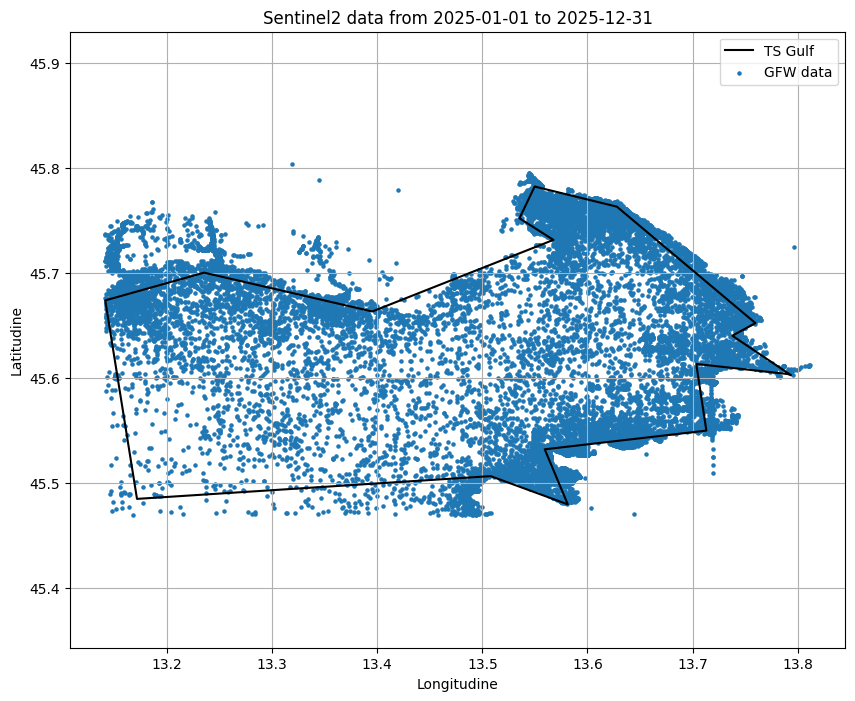

In [12]:
plt.figure(figsize=(10,8))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(gfw_unq_coords[lon_name], gfw_unq_coords[lat_name], label = 'GFW data', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.title(f"Sentinel2 data from {start_date} to {end_date}")

plt.show()

In [13]:
df.shape[0]

20627